# 04 – Multiple Lineare Regression

Erstes "echtes" ML-Modell nach den naiven Baselines.  
Zwei Varianten werden verglichen:

| Modell | Features |
|---|---|
| **Model A** | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures) |
| **Model B** | + `hour_sin/cos`, `day_sin/cos` (8 Features, **mit** Zeitfeatures) |

**Forschungshypothesen:**
- **H2:** Zeitliche Merkmale (Uhrzeit, Jahreszeit) verbessern die Prognose signifikant (MAE(mit Zeit) < MAE(ohne))

## 0 · Setup

In [49]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path
from scipy import stats

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data.preprocessing import (
    load_pv_data, load_weather_data, load_irradiance_data,
    merge_features,
)
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import (
    add_time_features, add_irradiance_features,
)
from src.models.baseline import train_linear_baseline, predict
from src.evaluation.metrics import evaluate, evaluate_by_season, persistence_forecast

P_NOM       = 13_500.0
TARGET      = "Solarproduktion"
RESULTS_DIR = Path("../results/04_linear_regression")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Model A: nur Strahlung + Wetter (ohne Zeitfeatures)
FEATURES_A = [
    "ghi_cloudy_sky", "clear_sky_index",
    "temperature_2m", "cloud_cover_low",
]
# Model B: + zyklische Zeitfeatures (H3)
FEATURES_B = [
    "ghi_cloudy_sky", "clear_sky_index",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "temperature_2m", "cloud_cover_low",
]

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Daten laden & mergen

In [50]:
pv_df  = load_pv_data()
w_df   = load_weather_data()
irr_df = load_irradiance_data()

df = merge_features(pv_df, w_df, irr_df)
print(f"Shape nach Merge: {df.shape}")
df[["timestamp", TARGET, "ghi_cloudy_sky", "temperature_2m", "cloud_cover_low"]].head(3)

Shape nach Merge: (117636, 22)


,timestamp,Solarproduktion,ghi_cloudy_sky,temperature_2m,cloud_cover_low
0,2022-02-07 14:00:00,192,NaN,4.1,13
1,2022-02-07 14:15:00,206,NaN,4.1,13
2,2022-02-07 14:30:00,206,NaN,4.1,13


## 2 · Feature Engineering

Warum genau diese Features?

| Feature                  | Quelle      | Warum?                                                                                                                                                                                                                                  |
|--------------------------|-------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `ghi_cloudy_sky`         | Irradiance  | Wichtigster PV-Treiber: Globalstrahlung unter realen Bedingungen                                                                                                                                                                        |
| `clear_sky_index`        | Irradiance  | GHI / GHI_clear – normiert Strahlung auf den theoretischen Klarhimmelwert; entkoppelt Bewölkungseffekt von Tageszeit und Jahreszeit. Ergänzt `ghi_cloudy_sky`, weil es unabhängig vom Sonnenstand ist. Wertebereich 0–1 (im Datensatz). |
| `hour_sin/cos`           | Timestamp   | **Zyklisch** codierte Stunde – Stunde 23 ist benachbart zu Stunde 0! *(nur Model B)*                                                                                                                                                    |
| `day_sin/cos`            | Timestamp   | **Zyklisch** codierter Jahrestag – erfasst Saisonalität korrekt *(nur Model B)*                                                                                                                                                         |
| `temperature_2m`         | Wetter      | Hohe Temperatur senkt den Wirkungsgrad (meist −0,3 bis −0,45%/K)                                                                                                                                                                        |
| `cloud_cover_low`        | Wetter      | Niedrige Wolken blockieren Direktstrahlung am stärksten                                                                                                                                                                                 |

> **Warum sin/cos statt Stunde als Integer?**  
> Lineare Regression erkennt nicht, dass Stunde 23 und Stunde 0 benachbart sind.  
> `sin(2π·h/24)` und `cos(2π·h/24)` stellen diese Zyklizität korrekt dar.  
> Model A verzichtet bewusst auf diese Features – so lässt sich ihr Beitrag isoliert messen (H3).

In [51]:
df = add_time_features(df)
df = add_irradiance_features(df)

print(f"Feature-Matrix: {df.shape[1]} Spalten")
df[FEATURES_B + [TARGET]].dropna().describe().round(2)

Feature-Matrix: 32 Spalten


,ghi_cloudy_sky,clear_sky_index,hour_sin,hour_cos,day_sin,day_cos,temperature_2m,cloud_cover_low,Solarproduktion
count,117627.00,117627.00,117627.00,117627.00,117627.00,117627.00,117627.00,117627.00,117627.00
mean,43.94,0.44,-0.00,-0.00,0.08,-0.02,10.84,29.05,363.20
std,63.86,0.46,0.71,0.71,0.71,0.69,8.03,39.10,652.75
min,0.00,0.00,-1.00,-1.00,-1.00,-1.00,-13.50,0.00,0.00
25%,0.00,0.00,-0.71,-0.71,-0.64,-0.71,4.70,0.00,0.00
50%,0.98,0.25,0.00,-0.00,0.18,-0.03,10.40,5.00,2.00
75%,73.70,1.00,0.71,0.71,0.79,0.66,16.70,55.00,542.00
max,228.44,1.00,1.00,1.00,1.00,1.00,36.90,100.00,8668.00


### Verteilungen & Transformationsüberlegungen

Die `describe()`-Ausgabe zeigt starke Schiefe bei mehreren Features. Ob Transformationen helfen, hängt vom Modelltyp ab:

| Feature | Verteilung | Lineare Regression | Random Forest / XGBoost |
|---|---|---|---|
| `ghi_cloudy_sky` | Stark rechtsschief (median≈1, max=228, ~50 % Nullen) | **log1p** empfohlen – linearisiert Beziehung zum Target | Nicht nötig (baumsplit-invariant) |
| `cloud_cover_low` | Rechtsschief (median=5, max=100) | **sqrt** sinnvoll – mildere Korrektur als log | Nicht nötig |
| `clear_sky_index` | 0–1, uniform bei Tag; 50 % Nullen (Nacht) | Keine Transformation | Ggf. Kategorisierung (Nacht / bewölkt / klar) |
| `temperature_2m` | Annähernd symmetrisch (−13 bis +37 °C) | Keine Transformation | Keine Transformation |

> **Hinweis für lineare Regression:** Wenn `ghi_cloudy_sky` per log1p transformiert wird, sollte das **Target unverändert** bleiben, um die Rücktransformation in `evaluate()` zu vermeiden. Die Transformationen sind in diesem Notebook *nicht* angewendet – sie werden ggf. in `04b_feature_importance` evaluiert.

## 3 · Train / Val / Test Split

In [52]:
train, val, test = time_series_split(df)

train = train.dropna(subset=FEATURES_B + [TARGET])
val   = val.dropna(subset=FEATURES_B + [TARGET])
test  = test.dropna(subset=FEATURES_B + [TARGET])

split_summary(train, val, test)

,von,bis,n,anteil
split,,,,
train,2022-02-07,2024-06-14,82338,70.0%
val,2024-06-14,2024-12-15,17645,15.0%
test,2024-12-15,2025-06-16,17644,15.0%


## 4 · Modell trainieren

In [53]:
# Targets und Features trennen; timestamp als Index
y_train = train.set_index("timestamp")[TARGET]
y_val   = val.set_index("timestamp")[TARGET]
y_test  = test.set_index("timestamp")[TARGET]

X_train = train.set_index("timestamp")[FEATURES_B]
X_val   = val.set_index("timestamp")[FEATURES_B]
X_test  = test.set_index("timestamp")[FEATURES_B]

# Model A: Strahlung + Wetter (ohne Zeitfeatures)
model_a = train_linear_baseline(X_train[FEATURES_A], y_train)

# Model B: + zyklische Zeitfeatures hour_sin/cos, day_sin/cos
model_b = train_linear_baseline(X_train[FEATURES_B], y_train)

print(f"Model A (ohne Zeit): {len(FEATURES_A)} Features   |   Model B (mit Zeit): {len(FEATURES_B)} Features")

Model A (ohne Zeit): 4 Features   |   Model B (mit Zeit): 8 Features


## 5 · Evaluation

Als Referenz-Baseline wird die **Day-Ahead-Persistenz** verwendet:

> **Persistenz-Naive:** Prognose für Tag *t* = gemessene Produktion von Tag *t−1*  
> (gleiche Uhrzeit, 96 × 15-min-Schritte zurück)  
> → einfachster naiver Ansatz; setzt voraus, dass der heutige Tag dem gestrigen gleicht.

Skill Score > 0 bedeutet: das Modell schlägt diesen naiven Ansatz.

In [54]:
pred_a_val  = predict(model_a, X_val[FEATURES_A])
pred_b_val  = predict(model_b, X_val[FEATURES_B])
pred_a_test = predict(model_a, X_test[FEATURES_A])
pred_b_test = predict(model_b, X_test[FEATURES_B])

# Persistence als Referenz (naiv: Vortagswert)
pers_val  = persistence_forecast(y_val)
pers_test = persistence_forecast(y_test)

rows = {}
for name, yt, yp, yr in [
    ("Persistence (val)",           y_val,  pers_val,    None),
    ("Model A – ohne Zeit (val)",   y_val,  pred_a_val,  pers_val),
    ("Model B – mit Zeit (val)",    y_val,  pred_b_val,  pers_val),
    ("Persistence (test)",          y_test, pers_test,   None),
    ("Model A – ohne Zeit (test)",  y_test, pred_a_test, pers_test),
    ("Model B – mit Zeit (test)",   y_test, pred_b_test, pers_test),
]:
    rows[name] = evaluate(yt, yp, P_NOM, y_ref=yr)

results_df = pd.DataFrame(rows).T
results_df[["rmse", "mae", "r2", "nrmse", "skill_mae"]].round(4)

,rmse,mae,r2,nrmse,skill_mae
Persistence (val),578.6002,211.3265,0.2111,0.0429,0.0000
Model A – ohne Zeit (val),478.9212,241.5969,0.4576,0.0355,-0.1406
Model B – mit Zeit (val),442.0344,237.7933,0.5379,0.0327,-0.1234
Persistence (test),593.8560,208.4590,0.1670,0.0440,0.0000
Model A – ohne Zeit (test),474.3042,219.7088,0.4665,0.0351,-0.0582
Model B – mit Zeit (test),451.2972,237.6771,0.5170,0.0334,-0.1421


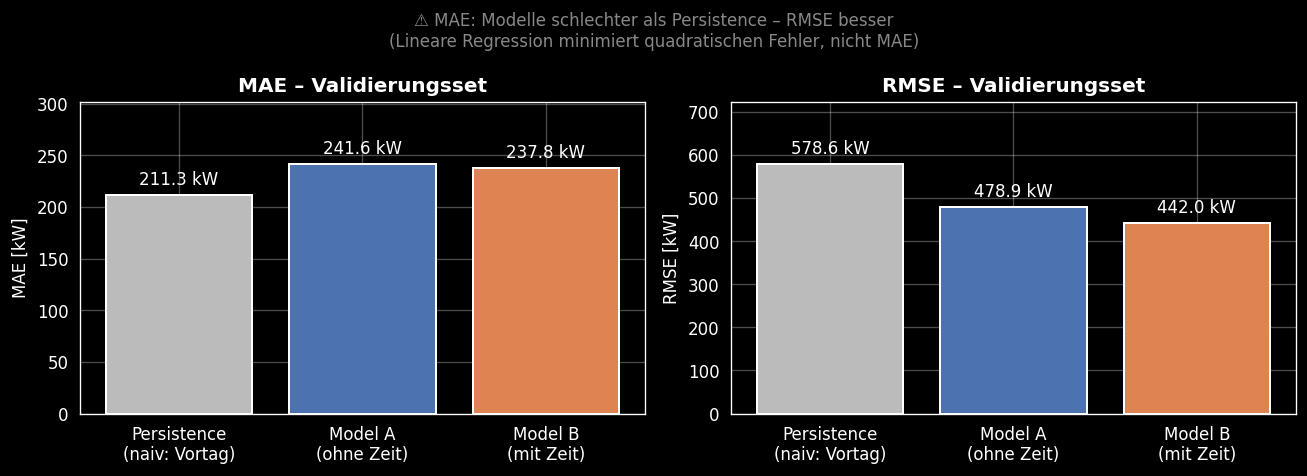

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

models = ["Persistence (val)", "Model A – ohne Zeit (val)", "Model B – mit Zeit (val)"]
labels = ["Persistence\n(naiv: Vortag)", "Model A\n(ohne Zeit)", "Model B\n(mit Zeit)"]
colors = ["#bbb", "#4C72B0", "#DD8452"]

for ax, metric, title in [
    (axes[0], "mae",  "MAE – Validierungsset"),
    (axes[1], "rmse", "RMSE – Validierungsset"),
]:
    vals = [results_df.loc[m, metric] for m in models]
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.1f kW", padding=4, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(f"{metric.upper()} [kW]")
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle(
    "⚠ MAE: Modelle schlechter als Persistence – RMSE besser\n"
    "(Lineare Regression minimiert quadratischen Fehler, nicht MAE)",
    fontsize=10, color="#888"
)
plt.tight_layout()
plt.show()

## 6 · Beispielwoche

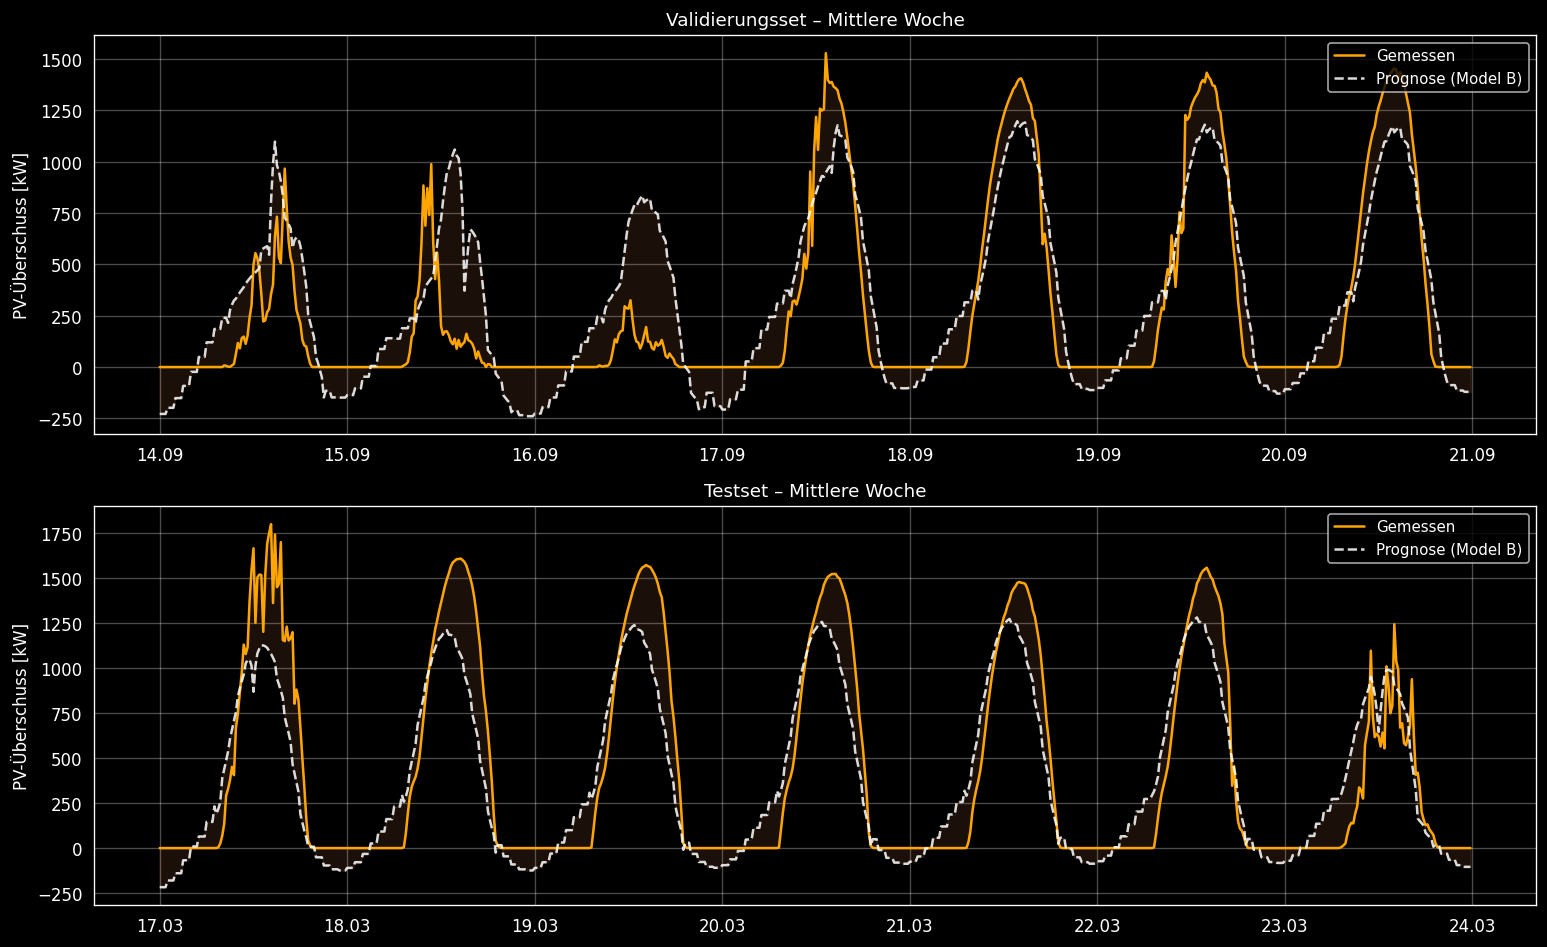

In [56]:
def plot_week(ax, df_split, y_pred, title):
    mid  = df_split["timestamp"].iloc[len(df_split) // 2].floor("D")
    mask = (df_split["timestamp"] >= mid) & (
           df_split["timestamp"] <  mid + pd.Timedelta(days=7))
    sub  = df_split[mask].set_index("timestamp")
    pred = y_pred.reindex(sub.index)

    ax.plot(sub.index, sub[TARGET], label="Gemessen",
            color="orange", linewidth=1.5)
    ax.plot(sub.index, pred, label="Prognose (Model B)",
            color="white", linewidth=1.5, linestyle="--", alpha=0.85)
    ax.fill_between(sub.index, sub[TARGET], pred, alpha=0.12, color="#DD8452")
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.legend(loc="upper right", fontsize=9)
    ax.set_ylabel("PV-Überschuss [kW]")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
plot_week(axes[0], val,  pred_b_val,  "Validierungsset – Mittlere Woche")
plot_week(axes[1], test, pred_b_test, "Testset – Mittlere Woche")
plt.tight_layout()
plt.show()

## 7 · Residualanalyse

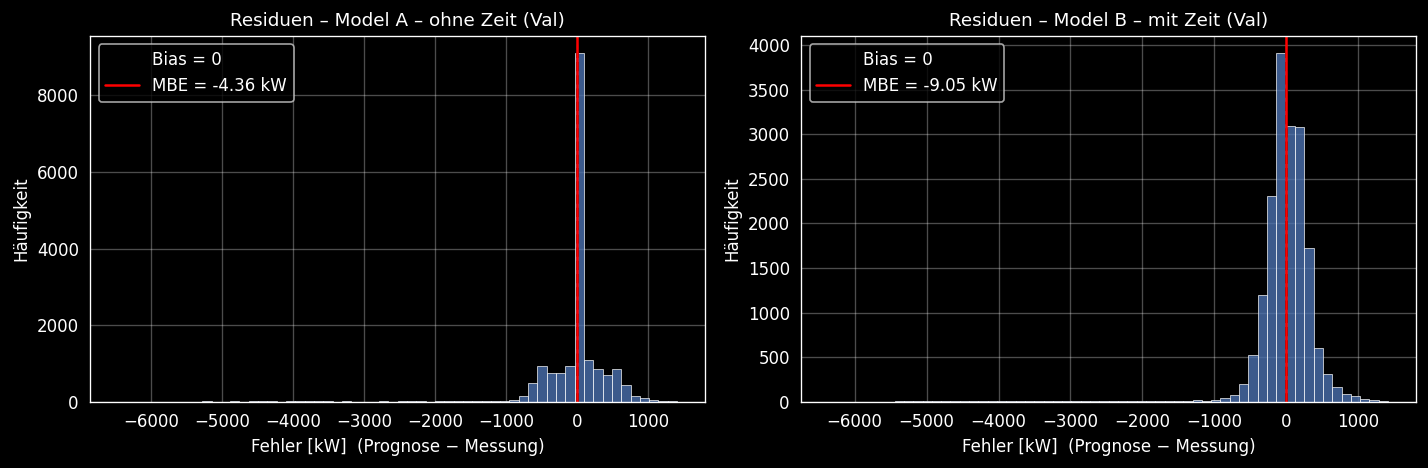

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, yt, yp in [
    (axes[0], "Model A – ohne Zeit (Val)", y_val, pred_a_val),
    (axes[1], "Model B – mit Zeit (Val)",  y_val, pred_b_val),
]:
    res = (yp - yt).dropna()
    ax.hist(res, bins=60, color="#4C72B0", edgecolor="white",
            linewidth=0.5, alpha=0.8)
    ax.axvline(0,           color="black", lw=1.5, ls="--", label="Bias = 0")
    ax.axvline(res.mean(),  color="red",   lw=1.5, ls="-",
               label=f"MBE = {res.mean():.2f} kW")
    ax.set_title(f"Residuen – {name}", fontsize=11)
    ax.set_xlabel("Fehler [kW]  (Prognose − Messung)")
    ax.set_ylabel("Häufigkeit")
    ax.legend()

plt.tight_layout()
plt.show()

## 8 · Forschungshypothesen

| Hypothese | H₀ | H₁ | Ergebnis |
|---|---|---|---|
| **H2** – Wetter/Strahlung vs. naive Baseline | MAE(ML) ≥ MAE(naiv) | MAE(ML) < MAE(naiv) | Skill Score (MAE) > 0? |
| **H3** – Zeitfeatures (Stunde, Jahrestag) | MAE(mit Zeit) ≥ MAE(ohne Zeit) | MAE(mit Zeit) < MAE(ohne Zeit) | Model B < Model A? |
| **H4** – Nichtlinear > Linear | MAE(nichtlinear) ≥ MAE(linear) | MAE(nichtlinear) < MAE(linear) | → Nächste Notebooks |

In [58]:
mae_pers = results_df.loc["Persistence (val)",          "mae"]
mae_a    = results_df.loc["Model A – ohne Zeit (val)",  "mae"]
mae_b    = results_df.loc["Model B – mit Zeit (val)",   "mae"]
sk_a     = results_df.loc["Model A – ohne Zeit (val)",  "skill_mae"]
sk_b     = results_df.loc["Model B – mit Zeit (val)",   "skill_mae"]

print("══ H2 – ML (ohne Zeit) vs. Persistence ══")
print(f"  MAE: Persistence {mae_pers:.1f} kW  →  Model A {mae_a:.1f} kW")
print(f"  Skill MAE (Model A): {sk_a:+.1%}  {'✓ bestätigt' if sk_a > 0 else '✗ nicht bestätigt'}")
print()
print("══ H3 – Einfluss Zeitfeatures ══")
print(f"  MAE: Model A (ohne Zeit) {mae_a:.1f} kW  →  Model B (mit Zeit) {mae_b:.1f} kW  (Δ = {mae_b - mae_a:+.1f} kW)")
print(f"  Skill MAE: A = {sk_a:+.1%}  |  B = {sk_b:+.1%}")

══ H2 – ML (ohne Zeit) vs. Persistence ══
  MAE: Persistence 211.3 kW  →  Model A 241.6 kW
  Skill MAE (Model A): -14.1%  ✗ nicht bestätigt

══ H3 – Einfluss Zeitfeatures ══
  MAE: Model A (ohne Zeit) 241.6 kW  →  Model B (mit Zeit) 237.8 kW  (Δ = -3.8 kW)
  Skill MAE: A = -14.1%  |  B = -12.3%


## 9 · Paired t-Test – H3 (Zeitfeatures)

Gepaarter einseitiger t-Test auf Absolutfehlern (Testset):

- **H₀:** MAE(ohne Zeitfeatures) ≤ MAE(mit Zeitfeatures)  
- **H₁:** MAE(ohne Zeitfeatures) > MAE(mit Zeitfeatures)  → Zeitfeatures helfen

Signifikanzniveau α = 0.05

In [59]:
ALPHA = 0.05

# Absolutfehler auf gemeinsamen Index (NaN-freie Schnittmenge)
ae_a = (pred_a_test - y_test).abs().dropna()
ae_b = (pred_b_test - y_test).abs().dropna()
common = ae_a.index.intersection(ae_b.index)
ae_a, ae_b = ae_a[common], ae_b[common]

# Einseitiger gepaarter t-Test: H1 = A > B (Zeitfeatures reduzieren Fehler)
t_stat, p_two = stats.ttest_rel(ae_a, ae_b)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

print(f"Stichprobengröße : n = {len(common):,}")
print(f"MAE Model A (ohne Zeit): {ae_a.mean():.2f} kW")
print(f"MAE Model B (mit Zeit) : {ae_b.mean():.2f} kW")
print(f"Mittlere Differenz (A−B): {(ae_a - ae_b).mean():+.2f} kW")
print()
print(f"t-Statistik : {t_stat:.4f}")
print(f"p-Wert (zweiseitig): {p_two:.4e}")
print(f"p-Wert (einseitig) : {p_one:.4e}")
print()
if p_one < ALPHA:
    print(f"→ H₀ abgelehnt (p = {p_one:.4e} < α = {ALPHA}):")
    print("  Zeitfeatures verbessern die Prognose signifikant. H3 ✓ bestätigt")
else:
    print(f"→ H₀ nicht abgelehnt (p = {p_one:.4e} ≥ α = {ALPHA}):")
    print("  Kein signifikanter Effekt der Zeitfeatures nachweisbar. H3 ✗ nicht bestätigt")

Stichprobengröße : n = 17,644
MAE Model A (ohne Zeit): 219.71 kW
MAE Model B (mit Zeit) : 237.68 kW
Mittlere Differenz (A−B): -17.97 kW

t-Statistik : -16.9114
p-Wert (zweiseitig): 1.1759e-63
p-Wert (einseitig) : 1.0000e+00

→ H₀ nicht abgelehnt (p = 1.0000e+00 ≥ α = 0.05):
  Kein signifikanter Effekt der Zeitfeatures nachweisbar. H3 ✗ nicht bestätigt


## 10 · Ergebnisse speichern

In [60]:
for model_name, yp_val, yp_test, feats in [
    ("linear_regression_A_ohne_zeit", pred_a_val, pred_a_test, FEATURES_A),
    ("linear_regression_B_mit_zeit",  pred_b_val, pred_b_test, FEATURES_B),
]:
    out = {
        "model":    model_name,
        "features": feats,
        "val":      evaluate(y_val,  yp_val,  P_NOM, y_ref=pers_val),
        "test":     evaluate(y_test, yp_test, P_NOM, y_ref=pers_test),
    }
    path = RESULTS_DIR / f"{model_name}.json"
    with open(path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Gespeichert: {path.name}")

Gespeichert: linear_regression_A_ohne_zeit.json
Gespeichert: linear_regression_B_mit_zeit.json
